In [1]:
from ra_archive_getter import ArchiveGetter
import os
import pandas as pd
from pathlib import Path
import contextlib
import io

In [2]:
max_pid = None
max_per_col = 64
max_per_manifest = 8 
max_images = 200

TIME = "20260414-0800"

model_path =  "C:\\RA_ufal_atrium\\atrium-page-classification-RA-fork-\\model_checkpoints\\model_ViT-B16_rev_main_10e.pt"
#model_path =  "C:\\RA_ufal_atrium\\atrium-page-classification-RA-fork-\\model_checkpoints\\model_ViT-B16_rev_main_10e.pt"
eval_path = ".\\transc_new"
path="transc_new"
out_path = "tranc_tested"
csv_path = path + "\\transc_new_images.csv"

In [3]:
#running = python run.py --directory "C:\\RA-CLIP\\test_set" --model_path "C:\RA_ufal_atrium\atrium-page-classification-RA-fork-\model_checkpoints\model_ViT-B16_rev_main_10e.pt"  --topn 2 --eval

In [4]:
# --- CONFIG ---
source_dir = r".\\result\\tables"          # där datum-csv:erna ligger
master_csv = r".\\transc_new\\transc_new_images.csv"    # csv som innehåller kolumnen "image_id"
output_csv = r".\\transc_new\\transc_new_images.csv" # där den sammanslagna csv:n ska sparas (kan vara samma som master_csv)

In [5]:
import os
import pandas as pd

def combine_csvs(source_dir, master_csv, output_csv, min_prefix):

    # --- STEG 1: hitta alla csv-filer med datum-prefix som är senare ---
    csv_files = []
    for f in os.listdir(source_dir):
        if not f.endswith(".csv"):
            continue

        prefix = f[:13]  # YYYYMMDD-HHMM

        if prefix[8] == "-" and prefix[:8].isdigit() and prefix[9:].isdigit():
            if prefix > min_prefix:
                csv_files.append(os.path.join(source_dir, f))

    import time

    # försök hitta CSV-filer upp till N gånger
    max_retries = 5
    retry_delay = 2  # sekunder

    for attempt in range(max_retries):
        if csv_files:
            break

        print(f"⚠️  Ingen ny CSV hittad (försök {attempt+1}/{max_retries}). Väntar {retry_delay}s...")
        time.sleep(retry_delay)

        # försök igen
        csv_files = []
        for f in os.listdir(source_dir):
            if not f.endswith(".csv"):
                continue

            prefix = f[:13]
            if prefix[8] == "-" and prefix[:8].isdigit() and prefix[9:].isdigit():
                if prefix > min_prefix:
                    csv_files.append(os.path.join(source_dir, f))

    # efter retries: fortfarande inga filer
    if not csv_files:
        print("❗ Ingen CSV hittades efter flera försök. Hoppar över combine_csvs denna gång.")
        return  # eller continue om du kör i loop


    # --- STEG 2: läs och kombinera ---
    dfs = [pd.read_csv(f) for f in csv_files]
    combined = pd.concat(dfs, ignore_index=True)

    # dessa csv: FILE,PAGE,CLASS-1,CLASS-2,SCORE-1,SCORE-2
    required_cols = {"FILE", "PAGE"}
    if not required_cols.issubset(combined.columns):
        raise RuntimeError(f"Combined CSVs must contain columns: {required_cols}")

    # --- STEG 3: läs master ---
    master = pd.read_csv(master_csv)

    if "image_id" not in master.columns:
        raise RuntimeError("Master CSV must contain column: image_id")

    # --- STEG 4: bygg match_key ---
    combined["PAGE"] = combined["PAGE"].astype(int)
    combined["match_key"] = combined["FILE"].astype(str) + "_" + combined["PAGE"].astype(str).str.zfill(5)

    master["match_key"] = master["image_id"].astype(str)

    # --- STEG 5: identifiera prediction-kolumner ---
    pred_cols = [c for c in combined.columns if c not in ["FILE", "PAGE", "match_key"]]

    # skapa reducerad combined
    combined_reduced = combined[["match_key"] + pred_cols]

    # --- STEG 6: merge med suffix ---
    merged = master.merge(combined_reduced, on="match_key", how="left", suffixes=("", "_new"))

    # --- STEG 7: idempotent uppdatering ---
    for col in pred_cols:
        new_col = col + "_new"
        if new_col in merged.columns:
            # uppdatera endast där master saknar värde
            merged[col] = merged[col].combine_first(merged[new_col])
            merged = merged.drop(columns=[new_col])

    # --- STEG 8: spara ---
    merged.to_csv(output_csv, index=False)
    print("Merged CSV saved to:", output_csv)

    # --- STEG 9: radera datum-csv ---
    for f in csv_files:
        try:
            os.remove(f)
            print("Deleted:", f)
        except Exception as e:
            print("Could not delete:", f, "Error:", e)


In [6]:
referenskoder = [
    "SE/RA/310180",
    "SE/RA/310180A",
    "SE/RA/310181",
    "SE/RA/310182",
    "SE/RA/310183",
    "SE/RA/310184",
    "SE/RA/310185",
    "SE/RA/310186",
    "SE/RA/310187",
    "SE/RA/420422",
    "SE/HLA/1040125",
    "SE/HLA/1040161",
    "SE/HLA/1070072",
    "SE/HLA/1070112",
    "SE/KrA/0082",
    "SE/LLA/10291",
    "SE/LLA/11086",
    "SE/RA/1134",	
    "SE/RA/420096",
    "SE/SSA/0138",
    "SE/VaLA/03825",
    "SE/GLA/12703",
    "SE/GLA/11675",
    "SE/GLA/11674",
    "SE/RA/6112",
    "SE/RA/6122",
    "SE/RA/420013",
    "SE/HLA/1090014",
    "SE/HLA/1270004",
    "SE/LLA/30091",
    "SE/RA/420013",   
    "SE/RA/720767",
    "SE/RA/757",
    "SE/ULA/10101",
    "SE/ULA/10102",
]

In [7]:
def count_images(root):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp"}
    total = 0

    for path, dirs, files in os.walk(root):
        for f in files:
            if os.path.splitext(f.lower())[1] in exts:
                total += 1

    return total

In [8]:
params = {
#        "year_min":1000,
#        "year_max":2025,
       "limit":1000,
#        
#        "facet":"ArchivalInstitution:Riksarkivet i Täby, Krigsarkivet",
        }

In [9]:
#import matplotlib
#matplotlib.use('Agg')  # Använd en icke-interaktiv backend
import matplotlib.pyplot as plt 
import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

In [10]:
import os
import shutil

def move_all_images(source_dir, target_dir, extensions=(".jpg", ".jpeg", ".png", ".tif", ".tiff")):
    """
    Letar efter alla bildfiler i source_dir och flyttar dem till target_dir.
    Skapar target_dir om den inte finns.
    Hoppar över filer som redan finns i target_dir.
    """

    # skapa mål-mapp om den saknas
    os.makedirs(target_dir, exist_ok=True)

    moved = 0
    skipped = 0

    # loopa över alla filer i source_dir
    for filename in os.listdir(source_dir):
        if not filename.lower().endswith(extensions):
            continue  # hoppa över icke-bilder

        src = os.path.join(source_dir, filename)
        dst = os.path.join(target_dir, filename)

        # om filen redan finns i target_dir → hoppa över
        if os.path.exists(dst):
            print(f"⏭️  Redan flyttad: {filename}")
            skipped += 1
            continue

        try:
            shutil.move(src, dst)
            print(f"➡️  Flyttad: {filename}")
            moved += 1
        except Exception as e:
            print(f"❌ Kunde inte flytta {filename}: {e}")

    print("\n--- Sammanfattning ---")
    print(f"Flyttade: {moved}")
    print(f"Redan flyttade: {skipped}")


In [11]:
from tqdm import tqdm
tqdm.disable = True

In [12]:
ag = ArchiveGetter()
ag.records.params = params

f = io.StringIO()
imgs_tot = 0
for ind,repref in enumerate(referenskoder):
    print(f"********************** {repref} **********************\n\n")
    with contextlib.redirect_stdout(f):
        ag.get_images(search=repref, path=path,max_total=max_images,
                max_per_manifest=max_per_manifest, max_per_collection=max_per_col, max_pids=max_pid)
    if count_images(path) >= 100:
        !python run.py --directory {path} --model_path {model_path} --topn 2
        with contextlib.redirect_stdout(f):
            combine_csvs(source_dir, master_csv, output_csv, TIME)
        #!python anno.py --csv_path {csv_path} --output_csv {csv_path} --image_dir {path}
        #move_all_images(path, "test_images")
            imgs_tot += count_images(path)
            print(f"Total images processed: {imgs_tot}")
            #ag.remove_images(path)
            move_all_images(path,out_path)
    if imgs_tot >= 10000:
        #print("Reached 500,000 images. Stopping.")
        break
        

********************** SE/RA/310180 **********************




KeyboardInterrupt: 

In [ ]:
%matplotlib inline


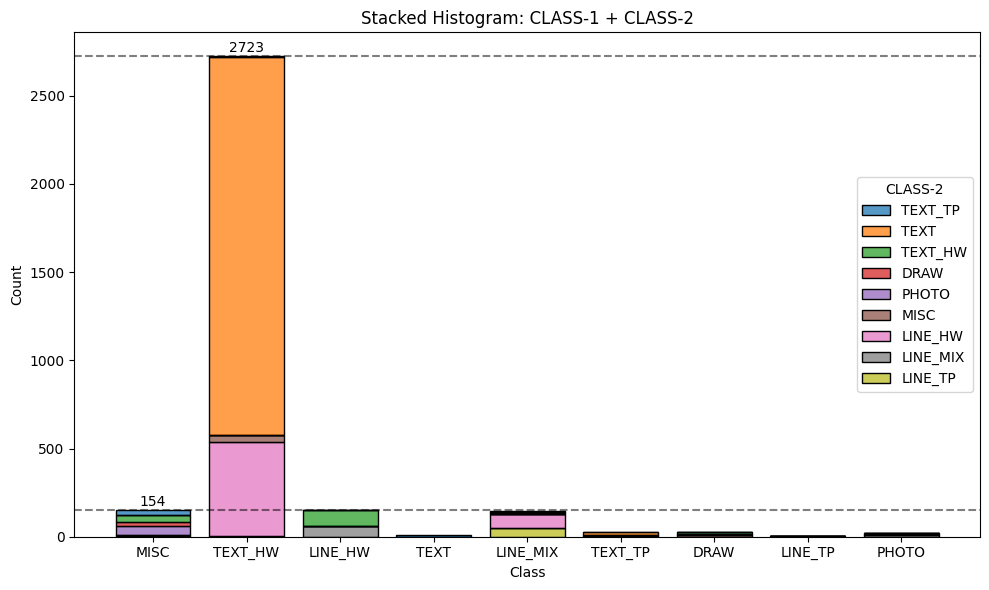

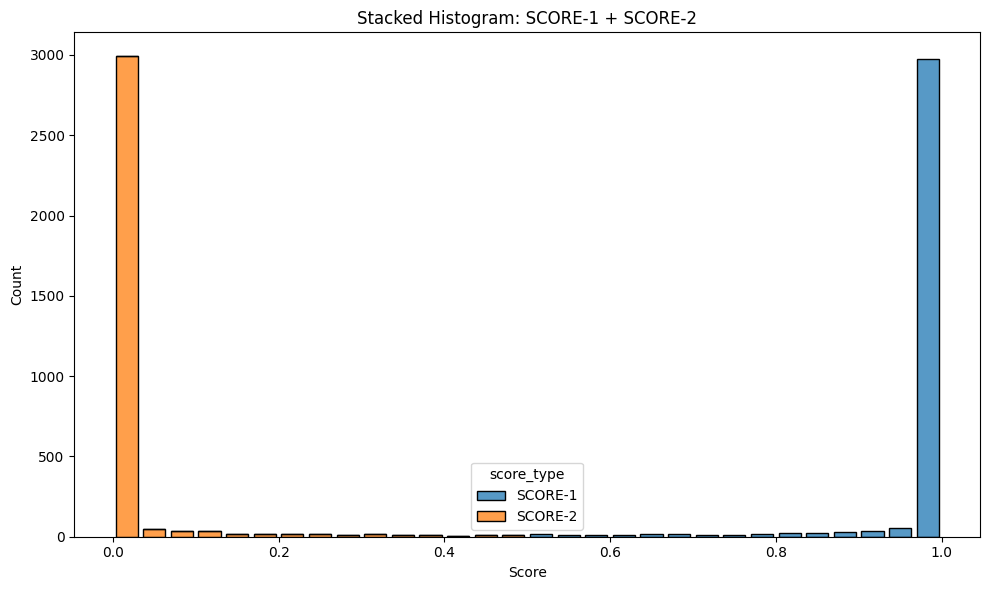

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

csv_path = output_csv

df = pd.read_csv(csv_path)
df = df.drop_duplicates(subset=["image_id"])
# --- CLASS histogram ---
plt.figure(figsize=(10, 6))
for i,j in enumerate(df["CLASS-1"].value_counts().values[:2]):
    plt.axhline(j,color="black", linestyle="dashed", alpha=0.5)
    plt.text(df["CLASS-1"].value_counts().index[i], j+5, f"{j}", ha="center", va="bottom", color="black", fontsize=10)
sns.histplot(
    data=df,
    x="CLASS-1",
    hue="CLASS-2",
    multiple="stack",
    shrink=0.8
)
plt.title("Stacked Histogram: CLASS-1 + CLASS-2")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- SCORE histogram ---
plt.figure(figsize=(10, 6))


sns.histplot(
    data=df.melt(value_vars=["SCORE-1", "SCORE-2"], var_name="score_type", value_name="score"),
    x="score",
    hue="score_type",
    multiple="stack",
    bins=30,
    shrink=0.8
)
plt.title("Stacked Histogram: SCORE-1 + SCORE-2")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

def compute_topk_accuracy(df):
    # säkerställ kolumner
    required = ["CLASS-1", "CLASS-2", "CLASS-3", "true_cat"]
    for col in required:
        if col not in df.columns:
            raise RuntimeError(f"Missing column: {col}")

    df["true"] = df["true_cat"].astype(str)

    # top‑1
    df["top1"] = df["CLASS-1"].astype(str)
    top1_acc = (df["top1"] == df["true"]).mean()

    # top‑2
    df["top2_hit"] = df.apply(
        lambda row: row["true"] in [str(row["CLASS-1"]), str(row["CLASS-2"])],
        axis=1
    )
    top2_acc = df["top2_hit"].mean()

    # top‑3
    df["top3_hit"] = df.apply(
        lambda row: row["true"] in [str(row["CLASS-1"]), str(row["CLASS-2"]), str(row["CLASS-3"])],
        axis=1
    )
    top3_acc = df["top3_hit"].mean()

    print("📊 ACCURACY")
    print(f"Top‑1: {top1_acc:.4f}")
    print(f"Top‑2: {top2_acc:.4f}")
    print(f"Top‑3: {top3_acc:.4f}")

    return top1_acc, top2_acc, top3_acc



In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

def show_topk_errors(df, image_dir, k=1, max_images=20):
    """
    Visar bilder där top‑k prediction INTE innehåller true_cat.
    k = 1, 2 eller 3
    """

    # säkerställ att k är giltigt
    if k not in [1, 2, 3]:
        raise ValueError("k måste vara 1, 2 eller 3")

    # skapa lista med top‑k predictions per rad
    df["topk_list"] = df.apply(
        lambda row: [
            str(row["CLASS-1"]),
            str(row["CLASS-2"]),
            str(row["CLASS-3"])
        ][:k],
        axis=1
    )

    # hitta felaktiga
    errors = df[df.apply(lambda row: str(row["true_cat"]) not in row["topk_list"], axis=1)]

    print(f"❌ Antal felaktiga top‑{k} predictioner: {len(errors)}")

    # visa bilder
    for idx, row in errors.head(max_images).iterrows():
        filename = row["local_filename"]
        true_label = row["true_cat"]
        preds = row["topk_list"]

        img_path = os.path.join(image_dir, filename)

        if not os.path.exists(img_path):
            print(f"⚠️ Bild saknas: {img_path}")
            continue

        img = Image.open(img_path)

        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Top-{k} preds: {preds}   |   True: {true_label}")
        plt.show()


In [ ]:
LABEL1 = "CLASS-1"
LABEL2 = "CLASS-2"
FILECOL = "local_filename"

In [ ]:
#import pandas as pd

In [ ]:
#from demo_folders import validate_csv

In [ ]:
#from demo_folders import sort_by_label, sort_second_level, check_missing_files,run_pipeline

In [ ]:
#!python run.py --directory {"C:\\RA-CLIP\\test_set"} --model_path {model_path} --topn 2

In [ ]:
#df = pd.read_csv("test_transc/test_transc_images.csv")

#run_pipeline(
#    image_folder="tranc_tested",
#    csv_path="transc_new/transc_new_images.csv",
#    label1="CLASS-1",
#    label2="CLASS-2",
#    filecol="local_filename"
#)


#print("\n=== DONE ===")


=== CSV VALIDATION ===
✓ No duplicates

=== FILE CHECK ===
✓ No missing files in folder
✓ No extra files in folder

=== SORTING BY CLASS-1 ===
Moved: 3255, Skipped: 0

=== SECOND-LEVEL SORTING BY CLASS-2 ===
Moved: 3255, Skipped: 0

=== DONE ===

=== DONE ===


: 